In [44]:
unquote_col = ["race", "race_o", "field"]
encoding_cols = ["gender", "race", "race_o", "field"]
preferences = ["attractive_important", "sincere_important", "intelligence_important", 
            "funny_important", "ambition_important", "shared_interests_important"]

preferences_partner = ["pref_o_attractive", "pref_o_sincere", "pref_o_intelligence", "pref_o_funny", "pref_o_ambitious",
                    "pref_o_shared_interests"]

rating_of_partner = ["attractive_partner", "sincere_partner", "intelligence_partner", "funny_partner",
                    "ambition_partner", "shared_interests_partner"]

continuos_valued = ["age","age_o","importance_same_race","importance_same_religion","pref_o_attractive",
                    "pref_o_sincere","pref_o_intelligence","pref_o_funny","pref_o_ambitious","pref_o_shared_interests",
                    "attractive_important","sincere_important","intelligence_important","funny_important",
                    "ambition_important", "shared_interests_important","attractive","sincere","intelligence","funny",
                    "ambition","attractive_partner","sincere_partner","intelligence_partner","funny_partner",
                    "ambition_partner","shared_interests_partner","sports","tvsports","exercise","dining","museums",
                    "art","hiking","gaming","clubbing","reading","tv","theater","movies","concerts","music","shopping",
                    "yoga","interests_correlate","expected_happy_with_sd_people","like"]

maxval_ten = [ "importance_same_race","importance_same_religion", "attractive","sincere","intelligence","funny",
                    "ambition","attractive_partner","sincere_partner","intelligence_partner","funny_partner",
                    "ambition_partner","shared_interests_partner","sports","tvsports","exercise","dining","museums",
                    "art","hiking","gaming","clubbing","reading","tv","theater","movies","concerts","music","shopping",
                    "yoga", "like", "expected_happy_with_sd_people"]


import csv

from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Performs label encoding in the database
# input:  the whole database already preprocessed
# output: a dictionary of encodings, indexed by each __encoding_cols__
# each index of the dictionary is lexicographically ordered, therefore the label the position of the value in this list
def label_encode(dic, enc_cols):
    # initialize the encoding dictionary
    enc = {}
    for enc_col in enc_cols:
        # we use sets for the label encoding, this way we always only add one element
        # each column in encoding_cols have a different set of label encodings
        enc[enc_col] = set()

    for row in dic:
        for enc_col in enc_cols:
            enc[enc_col].add(row[enc_col])
    
    for enc_col in enc_cols:
        enc[enc_col] = list(enc[enc_col])
        enc[enc_col].sort()

    return enc


def get_encoding(label, attr, encodings):
    for id, _label in enumerate(encodings[attr]):
        if label == _label:
            return id

    raise Exception

def encode_dic(dic, enc_cols, encodings):
    for row in dic:
        for attr in enc_cols:
            enc = get_encoding(row[attr], attr, encodings)
            row[attr] = enc
    
    return dic
            


def normalize(dic, prefs):
    total = 0

    # calculate total
    for row in dic:
        for preference in prefs:
            total += float(row[preference])

        # normalize
        for preference in prefs:
            row[preference] = float(row[preference]) / total
        total = 0
    

    return dic

# Unquotes the columns defined in __unquote_col__
# input: a row of dating-full in the form of dictionary
# output: (count, row)
#       count: number of unquoted cells
#       row: post processesd quote
def unquote(row):
    count = 0
    for col in unquote_col:
        cell = row[col]
        if cell.startswith("'") and cell.endswith("'") and len(cell) > 1:
            cell = cell.strip("'")
            count += 1
        if cell.startswith('"') and cell.endswith('"') and len(cell) > 1:
            cell = cell.strip('"')
            count += 1
        row[col] = cell
    return (count, row)

# Lowercases the __field__ column
# input: a row of dating-full in the form of a dictionary
# output: (count, row)
#       count: number of 
def tolower_field(row):
    count = 0
    if(not row["field"].islower()):
        count += 1
        row["field"] = row["field"].lower()
    return(count, row)

# Processes a dictionary by doing the following operations:
# 1 - unquote cells in unquote_col
# 2 - convert values in column field to lowercase
# input: csvDicReader
# output: (lower_count count, encodings, out_dic)
#       unq_count: number of unquoted cells
#       unq_count: number of lower cased field cells
#       label_encodings: encodings for the columns in encodings_val
#       outdic: preprocessed dictionary 
def preprocess(in_dic):
    unq_count = 0
    lower_count = 0
    out_dic = []
    for row in in_dic:
        c, row = unquote(row)
        c1, row = tolower_field(row)
        unq_count += c
        lower_count += c1
        out_dic.append(row)
    
    out_dic = normalize(out_dic, preferences)
    out_dic = normalize(out_dic, preferences_partner)
    # out_dic = encode_dic(out_dic, encoding_cols, label_encodings)
    #label_encodings = label_encode(out_dic, encoding_cols)
    return (unq_count, lower_count, out_dic)

def print_encodings(enc):
    for enc_col in encoding_cols:
        for id, val in enumerate(enc[enc_col]):
            if val == 'male' or (val == 'European/Caucasian-American' and enc_col == 'race') or (val == 'Latino/Hispanic American' and enc_col == 'race_o') or val == 'law':
                print("Value assigned for {} in column {}: {}".format(val, enc_col, id))
            

def print_means(dic):
    for pref in preferences + preferences_partner:
        col = [row[pref] for row in dic]
        print("Mean of {}: {}".format(pref, round(mean(col), 2)))
        



# Question 1

## i

In [45]:

with open('data/dating-full.csv', newline='') as csvfile:
    fulldata = csv.DictReader(csvfile, delimiter=',')
    unq_count, lower_count, dicdata = preprocess(fulldata)

    with open('data/dating.csv', 'w') as writefile:
        writer = csv.DictWriter(writefile, dicdata[0].keys())
        writer.writeheader()
        writer.writerows(dicdata)

## ii

In [46]:
import pandas as pd

#encoding_cols = ['race']

def get_pos(vec, v):
    for i, val in enumerate(vec):
        if v == val:
            return i
    raise IndexError("Position for val:{} doesn't exist".format(v)) 

def get_enc(sz, vals, val):
    vec = [0 for x in range(sz-1)]
    pos = get_pos(vals, val)
    try:
        if pos < sz - 1:
            vec[pos] = 1
    except IndexError:
        print(f"IndexError pos:{pos}")
        exit(1)
    return vec

def one_hot_encoding(df):
    for cat in encoding_cols:
        vals = sorted(df[cat].unique())
        n = len(vals)
        cols_name = [cat+"_"+name for name in vals[:-1]]
        
        df_x = pd.DataFrame(columns=cols_name)
        t = False

        if(cat=='gender'):
            v = 'female'
            t = True
        elif(cat=='race'):
            v = 'Black/African American'
            t = True
        elif(cat == 'race_o'):
            v = 'Other'
            t = True
        elif(cat =='field'):
            v = 'economics'
            t = True

        if t:
            vec = get_enc(n,vals,v)
            print("Mapped vector for {} in column {}: {}".format(v, cat, vec))
        # print(df_x)

        for i, row in df.iterrows():
            # vec = [0 for x in range(n-1)]
            # pos = get_pos(vals, row[cat]) 
            # try:
            #     if pos < n-1:
            #         vec[pos] = 1
            # except IndexError:
            #     print(f"IndexError pos:{pos}")
            #     exit(1)
            # df_x.loc(len(df_xjk)) = vec
            # print("vec: ", vec)
            # new_df = pd.DataFrame(vec, columns=cols_name)
            # df_x = pd.concat([df_x, new_df], ignore_index = True)
            vec = get_enc(n, vals, row[cat])
            df_x.loc[len(df_x)] = vec
            # print(vec)
            # print(new_df)
        # print(df_x)
        # print(f"original size: {len(df)} new size: {len(df_x)}")
        df = df.join(df_x)
    df = df.drop(columns=encoding_cols)
            
    """
    for idx, v in enumerate(vals):
        vec = [0 for x in range(n-1)]
        if not idx == n-1:
            vec[idx] = 1
        idxs = df.index[(df.index[df[cat] == v])] 
        for i in  idxs :
            df.at[i, cat] = vec

        if(cat=='gender' and v=='female') or (cat=='race' and v=='Black/African American') or \
            (cat=='race_o' and v=='Other') or (cat=='field' and v=='economics'):
            print("Mapped vector for {} in column {}: {}".format(v, cat, vec))
    """
    
    return df
    




In [47]:
data = pd.read_csv('data/dating.csv')

# FIXME: the handout asks to drop the last column, we are dropping the first
# hot_encoded = pd.get_dummies(data, columns = encoding_cols, drop_first=True)
# hot_encoded.to_csv('data/dating-hot.csv')

h = one_hot_encoding(data)

# print(h.keys())



Mapped vector for female in column gender: [1]
Mapped vector for Black/African American in column race: [0, 1, 0, 0]
Mapped vector for Other in column race_o: [0, 0, 0, 0]
Mapped vector for economics in column field: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## iii

In [48]:
test = h.sample(frac=0.2, replace=False, random_state=25)
train = h.drop(test.index)
train.to_csv('data/trainingSet.csv', index=False)
test.to_csv('data/testSet.csv', index=False)



# Question 2
## i

In [49]:
def sigmoid(z):
    # cc = np.clip(cc, -709.78, 709.78)
    # return 1 / (1 + np.exp(-z))
    return np.exp(z) / (1 + np.exp(z))

def lr(train, test, log=False):
    X = train.drop('decision', axis=1)
    Y = train['decision'].values.reshape(-1,1)

    X0 = test.drop('decision', axis=1)
    Y0 = test['decision'].values.reshape(-1,1)

    bias_arrayX = np.ones((X.shape[0], 1))
    X = np.hstack([bias_arrayX, X])
    bias_arrayX0 = np.ones((X0.shape[0], 1))
    X0 = np.hstack([bias_arrayX0, X0])

    _lambda = 0.01
    step = 0.005
    num_steps = 500
    tol = 1e-6

    w = np.zeros((X.shape[1], 1))

    train_accs = []
    test_accs = []
    train_acc = 0
    test_acc = 0

    for i in range(num_steps):
        w1 = np.array(w)

        p = sigmoid(np.dot(X, w))
        grad = np.dot(X.T, (p - Y)) / len(Y)
        w = w - step * (grad + _lambda * w)

        l2norm_diff = np.linalg.norm(w - w1, 2)
        if l2norm_diff < tol:
            print("break: l2norm: {} < tol: {}".format(l2norm_diff, tol))
        
        YTrain = np.round(sigmoid(np.dot(X,w)))
        cmp = (YTrain == Y)
        train_acc = np.sum(cmp) / len(cmp) * 100

        YTest = np.round(sigmoid(np.dot(X0,w)))
        cmp0 = (YTest == Y0)
        test_acc = np.sum(cmp0) / len(cmp0) * 100

        if i % 10 == 0:
            train_accs.append(train_acc)
            test_accs.append(test_acc)
            if log:
                print("Iteration ", i)
                print("Training Accuracy: {:.2f}".format(train_acc))
                print("Testing Accuracy: {:.2f}".format(test_acc))

    # return (train_accs, test_accs)
    return(train_acc, test_acc)


## ii

In [ ]:

def svm(train, test, plot = False, log = False):
    X = train.drop('decision', axis=1)
    Y = train['decision'].values.reshape(-1,1)
    Y[Y==0] = -1

    X0 = test.drop('decision', axis=1)
    Y0 = test['decision'].values.reshape(-1,1)
    Y0[Y0==0] = -1

    bias_arrayX = np.ones((X.shape[0], 1))
    X = np.hstack([bias_arrayX, X])
    bias_arrayX0 = np.ones((X0.shape[0], 1))
    X0 = np.hstack([bias_arrayX0, X0])

    tol = 1e-6
    step = .5
    _lambda = 0.01
    max_iter = 500
    weight_vec = np.zeros(X.shape[1])

    train_accs = []
    test_accs = []

    for i in range(max_iter):
        grad = 0
        for j in range(len(X)):
            sample_features = X[j]
            sample_label = Y[j]
            predicted_label = np.dot(weight_vec.T,sample_features)
            if sample_label * predicted_label < 1:
                sample_gradient = sample_label*sample_features
                i_grad = _lambda * weight_vec - sample_gradient
            else:
                i_grad = _lambda * weight_vec

            grad += i_grad

        grad = (1/len(X)) * grad
        weight_vec_upd = weight_vec-step * grad

        predicted_label_train = np.sign(np.dot(X, weight_vec_upd))
        predicted_label_test = np.sign(np.dot(X0, weight_vec_upd))
        train_accuracy = np.mean(predicted_label_train == Y) * 100
        test_accuracy = np.mean(predicted_label_test == Y0) * 100


        if i % 10 == 0:
            train_accs.append(train_accuracy)
            test_accs.append(test_accuracy)
            if log: 
                print("Iteration i: ", i)
                print("Training Accuracy: {:.2f}".format(train_accuracy))
                print("Testing Accuracy: {:.2f}".format(test_accuracy))
        
        l2norm_diff = np.linalg.norm(weight_vec - weight_vec_upd, 2)
        if l2norm_diff < tol:
            print("break: l2norm: {} < tol: {}".format(l2norm_diff, tol))
            break

        weight_vec = weight_vec_upd

    return (train_accuracy, test_accuracy)


## iii

In [ ]:

def lrsvm (trainingDataFileName, testDataFileName, modelIdx):
    train = pd.read_csv(trainingDataFileName)
    test = pd.read_csv(testDataFileName)
    if modelIdx == 1:
        return lr(train, test)
    elif modelIdx == 2:
        return svm(train, test)


In [50]:
train_acc, test_acc = lrsvm('data/trainingSet.csv', 'data/testSet.csv', 1)
print("Training Accuracy LR: {:.2f}".format(train_acc))
print("Testing Accuracy LR: {:.2f}".format(test_acc))

Training Accuracy LR: 70.88
Testing Accuracy LR: 70.20


In [51]:
train_accuracy, test_accuracy = lrsvm('data/trainingSet.csv', 'data/testSet.csv', 2)
print("Training Accuracy SVM: {:.2f}".format(train_accuracy))
print("Testing Accuracy SVM: {:.2f}".format(test_accuracy))

Training Accuracy SVM: 56.57
Testing Accuracy SVM: 57.55


# Question 3

## i

In [52]:
df = pd.read_csv('data/trainingSet.csv')

desired_len = 520 * 10
total = len(df)
sub = total-desired_len

df = df.sample(frac=1, random_state=18)

df.drop(df.tail(sub).index, inplace=True)

partitions = np.array_split(df, 10)



## ii

In [53]:
t_fracs = [0.025, 0.05, 0.075, 0.1, 0.15, 0.2]

svm_accs = []
lr_accs = []
nb_accs = []
log = False

out_svm = []
out_errsvm = []
out_lr = []
out_errlr = []

for t_frac in t_fracs:
    if log:
        print("=========================================")
        print("t_frac: {}".format(t_frac))
    for i in range(10):
        test_set = partitions[i]
        Sc = []
        for j in range(10):
            if j != i:
                Sc.append(partitions[j])
        Sc = pd.concat(Sc)
        train_set = Sc.sample(frac=t_frac, random_state=32)

        lr_train, lr_test = lr(train_set.copy(), test_set.copy())
        svm_train, svm_test = svm(train_set.copy(), test_set.copy())
        lr_accs.append(lr_test)
        svm_accs.append(svm_test)
        nb_accs.append(0)

        if log:
            print("i: ", i)
            print("LR train: ", lr_train)
            print("LR test: ", lr_test)
            print("SVM train: ", svm_train)
            print("SVM test: ", svm_test)
            print()

    svm_avg = np.mean(svm_accs)
    svm_stderr = np.std(svm_accs) / np.sqrt(10)
    # print(lr_accs)

    lr_avg = np.mean(lr_accs)
    lr_stderr = np.std(lr_accs) / np.sqrt(10)

    # print("t_frac: ", t_frac)
    # print("SVM Average Accuracy: ", svm_avg)
    # print("SVM Standard Error: ", svm_stderr)
    # print("LR Average Accuracy: ", lr_avg)
    # print("LR Standard Eoprror: ", lr_stderr)
    # print()

    out_svm.append(svm_avg)
    out_errsvm.append(svm_stderr)
    out_lr.append(lr_avg)
    out_errlr.append(lr_stderr)

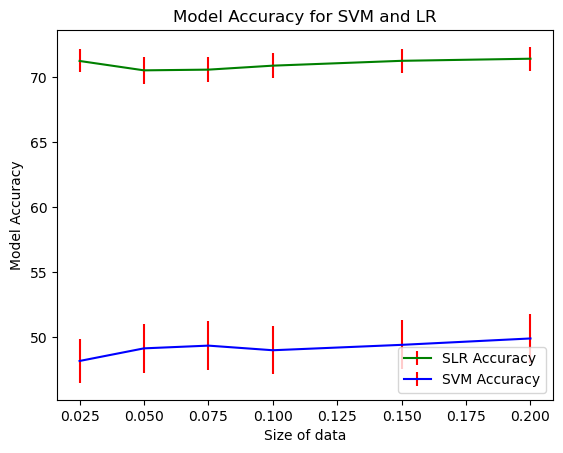

In [54]:

plt.errorbar(t_fracs, out_lr, yerr=out_errlr, ecolor='r', label='SLR Accuracy', color='green')
plt.errorbar(t_fracs, out_svm, yerr=out_errsvm, ecolor='r', label='SVM Accuracy', color='blue')
plt.xlabel('Size of data')
plt.ylabel('Model Accuracy')
plt.title('Model Accuracy for SVM and LR')
plt.legend()
plt.show()